# 04 Video Evaluation

Evaluate the trained CNN-LSTM model on the test set and analyze performance metrics.

### Key Features:
- **Path Stability**: Use `PROJECT_ROOT` to resolve all paths from the project base.
- **Metrics Reported**: Accuracy, Precision, Recall, F1 Score, Confusion Matrix.

In [2]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from pathlib import Path
import numpy as np
import cv2, json, yaml, os
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- PROJECT ROOT ---
PROJECT_ROOT = Path().resolve().parents[1]

CONFIG_PATH = PROJECT_ROOT / "configs" / "video_config.yaml"
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

DATA_PATH = PROJECT_ROOT / config["data"]["raw_path"]
MODEL_PATH = PROJECT_ROOT / config["data"]["model_save_path"]

IMG_SIZE = config["model"]["frame_size"]
FRAME_COUNT = config["model"]["frame_count"]
BATCH_SIZE = config["training"]["batch_size"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1. Model & Dataset Definition

In [3]:
# MODEL 

class DeepfakeVideoModel(nn.Module):
    def __init__(self, hidden_dim=256, dropout=0.3):
        super().__init__()

        backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])

        self.lstm = nn.LSTM(1280, hidden_dim, batch_first=True)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)

        f = self.feature_extractor(x).view(B*T, -1)
        f = f.view(B, T, -1)

        _, (h, _) = self.lstm(f)

        return self.fc(h[-1])


model = DeepfakeVideoModel(
    hidden_dim=config["model"]["hidden_dim"],
    dropout=config["model"]["dropout"]
).to(device)

# ✅ LOAD WEIGHTS
if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("✅ Model weights loaded")
else:
    raise FileNotFoundError("Model weights not found")

# DATASET

class VideoFrameDataset(Dataset):
    def __init__(self, video_list, num_frames, transform):
        self.video_list = video_list
        self.num_frames = num_frames
        self.transform = transform

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, idx):
        path, label = self.video_list[idx]

        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        indices = np.linspace(0, total-1, self.num_frames).astype(int)
        frames = []

        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()

            if not ret:
                frame = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

            frame = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            frame = self.transform(frame)
            frames.append(frame)

        cap.release()

        return torch.stack(frames), torch.tensor(label, dtype=torch.float32)

C:\Users\Asus\AppData\Local\Temp\ipykernel_5244\1896595679.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=dev

✅ Model weights loaded


## 2. Load Model & Prepare Evaluation

In [4]:
# DATA DISCOVERY (LIMITED TO PART_04)

def extract_part_number(name):
    try:
        return int(name.split('_')[-1])
    except:
        return None


def discover_dataset_parts(base_path, max_part=4):
    parts = []

    for item in os.listdir(base_path):
        p = Path(base_path) / item

        if item.startswith("dfdc_train_part_") and p.is_dir():
            num = extract_part_number(item)

            if num is not None and num <= max_part:
                if (p / "metadata.json").exists():
                    parts.append((p, num))

    parts.sort(key=lambda x: x[1])
    print("Using parts:", [x[1] for x in parts])

    return [x[0] for x in parts]


def get_video_list(parts):
    videos = []

    for part in parts:
        with open(part / "metadata.json") as f:
            meta = json.load(f)

        for file, info in meta.items():
            path = part / file
            if path.exists():
                label = 1 if info["label"] == "FAKE" else 0
                videos.append((str(path), label))

    return videos

# BUILD TEST LOADER

parts = discover_dataset_parts(DATA_PATH, max_part=4)
videos = get_video_list(parts)

test_videos = videos[-min(500, len(videos)):]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_loader = DataLoader(
    VideoFrameDataset(test_videos, FRAME_COUNT, transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)


Using parts: [0, 1, 2, 3, 4]


## 3. Evaluation Metrics

Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

         0.0       0.12      0.01      0.02       104
         1.0       0.79      0.98      0.88       396

    accuracy                           0.78       500
   macro avg       0.46      0.50      0.45       500
weighted avg       0.65      0.78      0.70       500



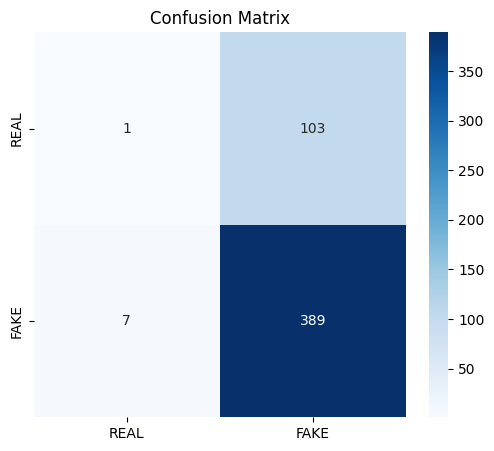

In [5]:
model.eval()

preds, targets = [], []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Evaluating"):
        x = x.to(device)
        y = y.to(device)

        out = model(x)
        prob = torch.sigmoid(out)

        preds.extend(prob.cpu().numpy())
        targets.extend(y.cpu().numpy())

preds = np.array(preds)
targets = np.array(targets)

preds_bin = preds >= 0.5

print("\nClassification Report:")
print(classification_report(targets, preds_bin))

cm = confusion_matrix(targets, preds_bin)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["REAL","FAKE"],
            yticklabels=["REAL","FAKE"])
plt.title("Confusion Matrix")
plt.show()